In [161]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [162]:
print(os.listdir("../data/raw")[0])

yellow_tripdata_2024-08.parquet


In [163]:
os.path.basename("../data/raw/yellow_tripdata_2024-08.parquet")

'yellow_tripdata_2024-08.parquet'

In [164]:
path = os.path.join("../data" , "raw", "yellow_tripdata_2024-08.parquet")
df = pd.read_parquet(path)

In [165]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2024-08-01 00:21:00,2024-08-01 00:36:13,1.0,7.40,1.0,N,138,80,1,28.9,7.75,0.5,7.65,0.00,1.0,45.80,0.0,1.75
1,2,2024-08-01 00:20:01,2024-08-01 00:41:47,1.0,9.91,1.0,N,138,239,1,40.8,6.00,0.5,11.55,6.94,1.0,71.04,2.5,1.75
2,1,2024-08-01 00:17:52,2024-08-01 00:41:45,0.0,13.40,1.0,N,138,88,1,52.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5,1.75
3,1,2024-08-01 00:49:08,2024-08-01 00:55:56,0.0,3.90,1.0,N,209,137,3,17.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5,0.00
4,1,2024-08-01 00:38:52,2024-08-01 00:42:34,1.0,0.40,1.0,N,148,144,2,5.1,3.50,0.5,0.00,0.00,1.0,10.10,2.5,0.00


In [166]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')

In [167]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          258667
trip_distance                 0
RatecodeID               258667
store_and_fwd_flag       258667
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     258667
Airport_fee              258667
dtype: int64

In [168]:
df = df.dropna(subset=[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "payment_type"
])

In [169]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])


In [170]:
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - 
                           df["tpep_pickup_datetime"]).dt.total_seconds() / 60

In [171]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

In [172]:
df = df[
    (df["trip_duration_min"] > 0) & 
    (df["trip_duration_min"] < 1440)
]

In [173]:
df["trip_speed_kmh"] = df["trip_distance"] / (df["trip_duration_min"] / 60)

In [174]:
df = df[
    df["trip_distance"] > 0
]

In [175]:
df["fare_per_km"] = df["fare_amount"] / df["trip_distance"]

In [176]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_min,pickup_hour,pickup_day,trip_speed_kmh,fare_per_km
0,1,2024-08-01 00:21:00,2024-08-01 00:36:13,1.0,7.40,1.0,N,138,80,1,...,0.00,1.0,45.80,0.0,1.75,15.216667,0,Thursday,29.178532,3.905405
1,2,2024-08-01 00:20:01,2024-08-01 00:41:47,1.0,9.91,1.0,N,138,239,1,...,6.94,1.0,71.04,2.5,1.75,21.766667,0,Thursday,27.316998,4.117053
2,1,2024-08-01 00:17:52,2024-08-01 00:41:45,0.0,13.40,1.0,N,138,88,1,...,0.00,1.0,78.75,2.5,1.75,23.883333,0,Thursday,33.663643,3.880597
3,1,2024-08-01 00:49:08,2024-08-01 00:55:56,0.0,3.90,1.0,N,209,137,3,...,0.00,1.0,22.00,2.5,0.00,6.800000,0,Thursday,34.411765,4.358974
4,1,2024-08-01 00:38:52,2024-08-01 00:42:34,1.0,0.40,1.0,N,148,144,2,...,0.00,1.0,10.10,2.5,0.00,3.700000,0,Thursday,6.486486,12.750000


In [177]:
df = df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "pickup_hour",
        "pickup_day",
        "trip_distance",
        "trip_duration_min",
        "trip_speed_kmh",
        "fare_amount",
        "fare_per_km",
        "passenger_count",
        'extra',
        'mta_tax',
        'tip_amount',
        'tolls_amount', 
        'improvement_surcharge',
        'total_amount', 
        'congestion_surcharge'
    ]
]

In [178]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5
2,2024-08-01 00:17:52,2024-08-01 00:41:45,0,Thursday,13.40,23.883333,33.663643,52.0,3.880597,0.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5
3,2024-08-01 00:49:08,2024-08-01 00:55:56,0,Thursday,3.90,6.800000,34.411765,17.0,4.358974,0.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5
4,2024-08-01 00:38:52,2024-08-01 00:42:34,0,Thursday,0.40,3.700000,6.486486,5.1,12.750000,1.0,3.50,0.5,0.00,0.00,1.0,10.10,2.5


In [179]:
# Basic statistics
print(df.describe())


             tpep_pickup_datetime       tpep_dropoff_datetime   pickup_hour  \
count                     2921704                     2921704  2.921704e+06   
mean   2024-08-16 04:37:38.424445  2024-08-16 04:55:08.206378  1.422880e+01   
min           2009-01-01 00:02:52         2009-01-01 20:28:16  0.000000e+00   
25%    2024-08-07 22:51:59.250000  2024-08-07 23:07:49.750000  1.100000e+01   
50%    2024-08-15 21:24:10.500000  2024-08-15 21:39:53.500000  1.500000e+01   
75%           2024-08-23 23:45:04  2024-08-24 00:01:24.250000  1.900000e+01   
max           2024-09-10 12:27:29         2024-09-10 19:45:57  2.300000e+01   
std                           NaN                         NaN  5.809093e+00   

       trip_distance  trip_duration_min  trip_speed_kmh   fare_amount  \
count   2.921704e+06       2.921704e+06    2.921704e+06  2.921704e+06   
mean    5.042068e+00       1.749637e+01    1.795203e+01  1.959369e+01   
min     1.000000e-02       1.666667e-02    6.272214e-04 -1.174100e+03

In [180]:
df.head(2)

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5


In [181]:
df["pickup_day"].value_counts()

pickup_day
Thursday     514291
Saturday     476074
Friday       469266
Wednesday    401327
Tuesday      391394
Monday       338633
Sunday       330719
Name: count, dtype: int64

In [182]:
print(df["pickup_hour"].value_counts())

pickup_hour
18    207558
17    202120
16    184645
15    180633
19    179983
14    176636
13    167719
20    167330
21    165103
12    159650
22    148190
11    146931
10    133118
9     122851
23    113136
8     107171
0      82266
7      72068
1      56474
6      45387
2      38755
3      25429
5      19923
4      18628
Name: count, dtype: int64


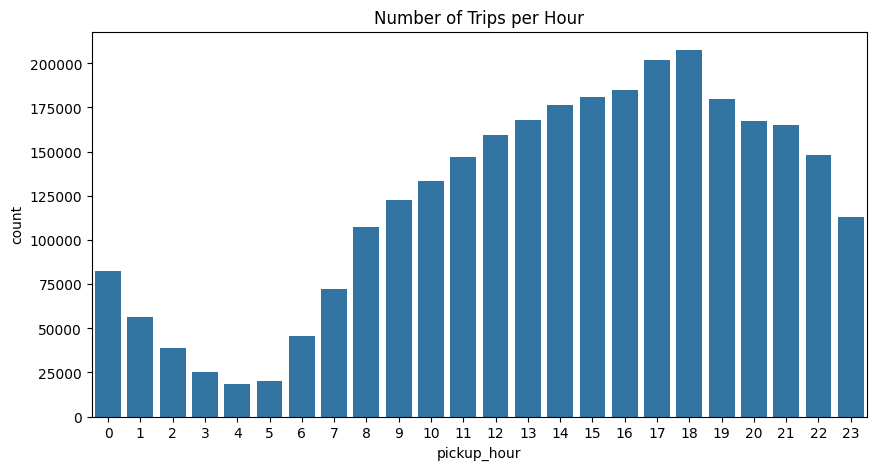

In [183]:
# Trips per hour 
plt.figure(figsize=(10,5))
sns.countplot(x="pickup_hour" , data=df)
plt.title("Number of Trips per Hour")
plt.show()

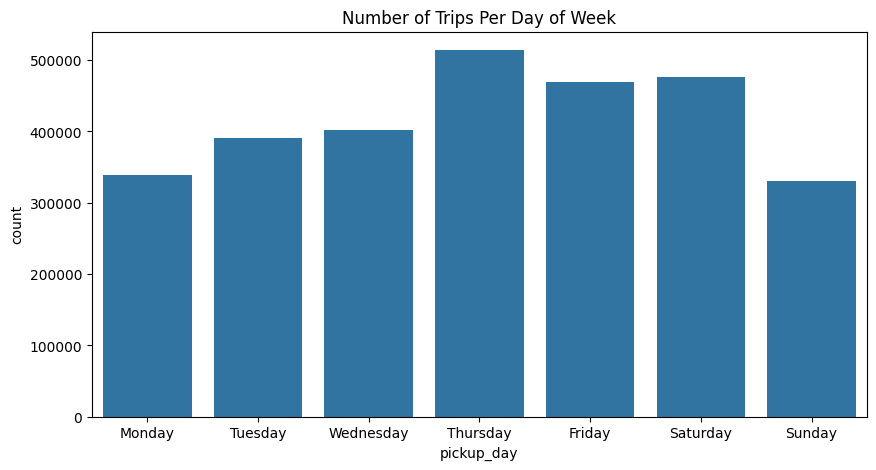

In [184]:
# Trips per day of week
plt.figure(figsize=(10,5))
sns.countplot(x="pickup_day" , data=df , order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Number of Trips Per Day of Week")
plt.show()

In [185]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day,trip_distance,trip_duration_min,trip_speed_kmh,fare_amount,fare_per_km,passenger_count,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2024-08-01 00:21:00,2024-08-01 00:36:13,0,Thursday,7.40,15.216667,29.178532,28.9,3.905405,1.0,7.75,0.5,7.65,0.00,1.0,45.80,0.0
1,2024-08-01 00:20:01,2024-08-01 00:41:47,0,Thursday,9.91,21.766667,27.316998,40.8,4.117053,1.0,6.00,0.5,11.55,6.94,1.0,71.04,2.5
2,2024-08-01 00:17:52,2024-08-01 00:41:45,0,Thursday,13.40,23.883333,33.663643,52.0,3.880597,0.0,10.25,0.5,15.00,0.00,1.0,78.75,2.5
3,2024-08-01 00:49:08,2024-08-01 00:55:56,0,Thursday,3.90,6.800000,34.411765,17.0,4.358974,0.0,3.50,0.5,0.00,0.00,1.0,22.00,2.5
4,2024-08-01 00:38:52,2024-08-01 00:42:34,0,Thursday,0.40,3.700000,6.486486,5.1,12.750000,1.0,3.50,0.5,0.00,0.00,1.0,10.10,2.5


In [186]:
duration_by_hour = df.groupby("pickup_hour")["trip_duration_min"].mean()
duration_by_hour

pickup_hour
0     15.657339
1     14.692541
2     13.478924
3     13.526208
4     15.185405
5     16.802391
6     17.104390
7     16.402408
8     16.675928
9     16.949207
10    17.551805
11    18.151868
12    18.592074
13    19.012331
14    19.702862
15    20.073775
16    20.042666
17    18.944801
18    16.933093
19    16.286538
20    15.821487
21    15.670710
22    15.914546
23    16.387735
Name: trip_duration_min, dtype: float64

In [187]:
distance_by_hour = df.groupby("pickup_hour")["trip_distance"].mean()  
distance_by_hour  

pickup_hour
0      4.497519
1      4.343856
2      4.652500
3      3.943253
4     21.341393
5     18.926461
6      9.086573
7     11.201810
8      4.376423
9      4.778917
10     4.058559
11     4.697162
12     4.727572
13     4.753637
14     5.063240
15     4.616141
16     4.804248
17     4.085867
18     4.993940
19     3.415904
20     5.651353
21     4.602467
22     4.609568
23     4.610348
Name: trip_distance, dtype: float64

In [188]:
# High Speed Trips

high_speed_trips = df[df["trip_speed_kmh"] > 110]
high_speed_trips.shape

(921, 17)

In [189]:
expensive_trips = df[df["total_amount"] > 250]
expensive_trips.shape

(1353, 17)